In [44]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

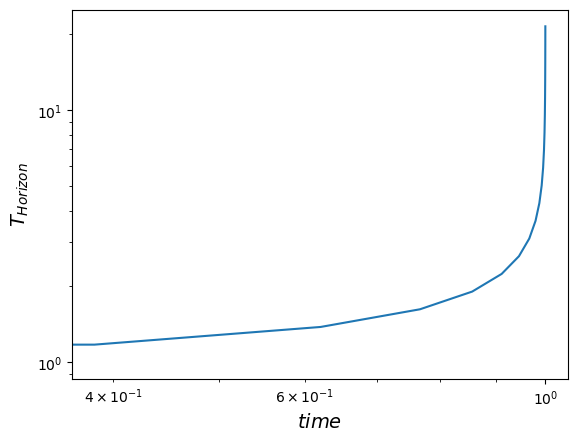

In [45]:
# --- 2. Boundary Condition Function ---
def Hawking_temperature(t, t_trans = 0):
    """Time-dependent temperature at the event horizon."""
    if t < t_trans:
        return 1.0
    else:
        # The Hawking radiation term: (1 - (t - t_trans))^(-1/3)
        return (1.0 - (t - t_trans))**(-1/3)

tau = np.linspace(-4,0,20)
time_grid = 1 - 10**tau
vec_func = np.vectorize(Hawking_temperature)
bh_temp = vec_func(time_grid, t_trans=0)

plt.loglog(time_grid,bh_temp)
plt.xlabel(r"$ time $", fontsize=14) 
plt.ylabel(r"$T_{Horizon}$", fontsize=14)
plt.show()

In [46]:
def Hawking_temperature_derivative(t, t_trans = 0):
    """Time-dependent time derivative temperature at the event horizon."""
    if t < t_trans:
       return 0.0 # T is constant 1.0
    else:
        # Derivative of (1 - (t - t_trans))^(-1/3) is (1/3)(1-(t-t_trans))^(-4/3)
       return (1/3) * (1.0 - (t - t_trans))**(-4/3)    

In [47]:
# --- Parameters ---
c = 100.0 # C is the diffusive constant. This is not physically relevant. the equation has a symmetry c * t = invariant.
r_min = 1.0 # Left boundary
r_max = 10**3. # right boundary
Nr = 800 
dr = (r_max - r_min) / (Nr - 1)
r = np.linspace(r_min, r_max, Nr)

t_trans = 0.0  # Time when evaporation acceleration begins
# Simulation ends just before the singularity at t_trans + 1
t_max = t_trans + 1.0 - 0.00001 

# Initial Condition at the end of the BH decay : T = r^(-7/11)
T_0 = 1.0 # not associated to any physical scale, we just want to understand the evolution and scaling behavior
T_ini = T_0 * (r_min / r)**(1/3)

In [48]:
#  pde : d(T^4)/dt = (c/r^2) * d/dr [ (r^2/T) * d(T^4)/dr ]

def heat_equation(t, T, c_coeff):
    """
    Calculates dT/dt for a non-linear heat equation.
    pde : d(T^4)/dt = (c/r^2) * d/dr [ (r^2/T) * d(T^4)/dr ]
    """
    T_safe = np.maximum(T, 1e-10) # to avoid instability due to small numbers
    T4 = T_safe**4
    
    # 1. Calculate Flux at cell interfaces (size Nr-1)
    # flux = (r^2 / T) * d(T^4)/dr
    r_face = (r[:-1] + r[1:]) / 2.0 # size Nr -1
    T_face = (T_safe[:-1] + T_safe[1:] ) / 2.0 # size Nr -1
    
    # d(T^4)/dr at the interfaces
    dT4_dr = np.diff(T4) / dr # size Nr -1
    
    flux = (r_face**2 / T_face) * dT4_dr # size Nr -1
    
    # 2. Apply Boundary Conditions (No Flux at r_min and r_max due to no heat source and no outside influence)
    # Pad the flux array with 0s at both the ends
    full_flux = np.concatenate([[0.0], flux, [0.0]]) # size Nr + 1
    
    # 3. Calculate Divergence of Flux at cell centers (size Nr)
    # div = (1/dr) * [J_right - J_left]
    flux_div = np.diff(full_flux) / dr
    
    # 4. d(T^4)/dt = (c / r^2) * flux_div
    dT4dt = (c_coeff / r**2) * flux_div
    
    # 5. Convert back to dT/dt: dT/dt = (dT4/dt) / (4 * T^3)
    dTdt = dT4dt / (4.0 * T_safe**3)

    dTdt[0] = Hawking_temperature_derivative(t, t_trans)
        
    # Outer boundary: Neumann (zero energy loss)
    dTdt[-1] = 0 
    
    return dTdt

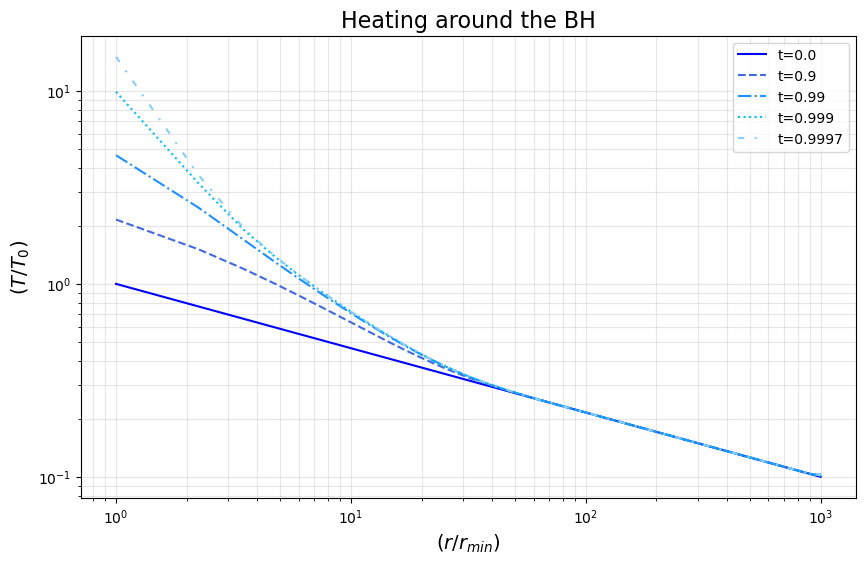

In [49]:
# --- Integration ---
t_span = (t_trans, t_max)
t_points = t_trans + np.array([0., 0.9, 0.99, 0.999, 0.9997]) # Avoid t=0 to prevent initial transient issues

# Using 'Radau' because non-linear diffusion is often a "stiff" problem
solution = solve_ivp(heat_equation, t_span, T_ini,
                     t_eval=t_points, args=(c,))

# --- Plotting ---
plt.figure(figsize=(10, 6))
colors = ['#0000FF', '#4169E1', '#1E90FF', '#00BFFF', '#87CEFA']
styles = ['solid', 'dashed', 'dashdot', 'dotted', (0, (3, 5, 1, 5))]

# solution.y is shaped (Nr, len(t_points))
for i in range(len(t_points)):
    plt.loglog(r, solution.y[:, i], color=colors[i], linestyle=styles[i], 
               label=f"t={t_points[i]}")

plt.xlabel(r"$(r/r_{min})$", fontsize=14)
plt.ylabel(r"$(T/T_0)$", fontsize=14)
plt.title("Heating around the BH", fontsize=16)
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()